# 💬 Spam Detection — Komentar YouTube Windah Basudara
### Perbandingan ML Klasik vs Transformer (IndoBERT Fine-Tuned)

> Proyek ini membangun dan membandingkan sistem deteksi spam komentar YouTube menggunakan berbagai pendekatan: dari **Machine Learning klasik** (TF-IDF + Word2Vec) hingga **Transformer berbasis IndoBERT** yang telah di-fine-tune khusus untuk konteks judi online (judol) Indonesia.

---

**👥 Anggota Tim:**
| Nama | NIM |
| :--- | :---: |
| **Rafa Al Razzak** | 0110224155 |
| **Muhamad Fadil** | 0110224112 |
| **Raffa Yuda Pratama** | 0110224081 |
| **Aan Adriana** | 0110224014 |
| **Oryza Ayunda Putri** | 0110224030 |

---

**🗺️ Alur Notebook:**
```
1. Setup & Install          → Install semua dependensi
2. Data Collection          → Load dataset dari Google Drive
3. EDA                      → Eksplorasi dan visualisasi data
4. Preprocessing            → Cleaning teks
5. Feature Extraction       → TF-IDF & Word2Vec
6. ML Models (5 model)      → NB, LR, SVM, RF, XGBoost
7. Transformer: IndoBERT    → Fine-tuned judol-detector
8. Evaluasi & Perbandingan  → Tabel + visualisasi lengkap
9. Analisis Kesalahan       → Error analysis
10. Simpan Artifacts        → Export semua model
11. Deployment Gradio       → Aplikasi interaktif
12. Kesimpulan
```


---
## ⚙️ Bagian 1 — Setup & Instalasi

Install semua library yang dibutuhkan. Jalankan cell ini sekali di awal.

| Library | Kegunaan |
|---|---|
| `scikit-learn` | Model ML klasik + evaluasi |
| `gensim` | Word2Vec embedding |
| `xgboost` | Model gradient boosting |
| `transformers` + `torch` | IndoBERT inference |
| `gradio` | UI deployment |
| `imbalanced-learn` | Penanganan class imbalance (SMOTE) |


In [1]:
# ── Install dependencies ─────────────────────────────────────────────────────
import subprocess, sys

packages = [
    "gensim", "nltk", "xgboost", "lightgbm",
    "transformers", "torch", "gradio",
    "imbalanced-learn", "scikit-learn", "pandas",
    "numpy", "matplotlib", "seaborn", "joblib"
]

print("📦 Installing packages...")
subprocess.run(
    [sys.executable, "-m", "pip", "install", "--quiet"] + packages,
    check=True
)
print("✅ Semua package berhasil diinstall!")

📦 Installing packages...
✅ Semua package berhasil diinstall!


In [2]:
# ── Import semua library ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import warnings
import time
import joblib
from pathlib import Path
from collections import Counter

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# ML Models
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

# Model Selection & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)

# Handling imbalance
from imblearn.over_sampling import SMOTE

# Transformer
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Konfigurasi global
warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette("Set2")

# Download NLTK resources
for resource in ['stopwords', 'punkt', 'punkt_tab']:
    nltk.download(resource, quiet=True)

print("✅ Semua library berhasil diimport!")
print(f"   PyTorch version : {torch.__version__}")
print(f"   Device          : {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")


✅ Semua library berhasil diimport!
   PyTorch version : 2.10.0+cpu
   Device          : CPU


---
## 📦 Bagian 2 — Pengumpulan Data

Dataset berisi komentar live stream Windah Basudara yang sudah dilabeli:
- **Label 0** → Komentar normal (Ham/Safe)
- **Label 1** → Komentar spam/judol (Blocked)


In [3]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
FILE_ID = '1jpLSLu8tXsJxDOBzczFk_wrbmkZGosFD'
URL = f'https://drive.google.com/uc?export=download&id={FILE_ID}'

print("⏳ Mengunduh dataset...")
df_raw = pd.read_csv(URL)
df = df_raw.dropna(subset=['text', 'predicted_label']).reset_index(drop=True)

# Pastikan tipe kolom label benar
df['predicted_label'] = df['predicted_label'].astype(int)

print(f"✅ Dataset berhasil dimuat!")
print(f"   Total baris    : {len(df):,}")
print(f"   Total kolom    : {len(df.columns)}")
print(f"   Missing values : {df.isnull().sum().sum()}")
print()
print("Distribusi Label:")
vc = df['predicted_label'].value_counts()
for label, count in vc.items():
    name = "🚫 Spam/Judol" if label == 1 else "✅ Ham/Safe"
    print(f"   {name} ({label}): {count:,} ({count/len(df)*100:.1f}%)")


⏳ Mengunduh dataset...
✅ Dataset berhasil dimuat!
   Total baris    : 16,798
   Total kolom    : 2
   Missing values : 0

Distribusi Label:
   ✅ Ham/Safe (0): 11,883 (70.7%)
   🚫 Spam/Judol (1): 4,915 (29.3%)


In [4]:
# Preview data
df.head(10)


,text,predicted_label
0,"What a game, ini game terbaik dari Joy Kreatif...",1
1,mantap bg,0
2,Itu ending 6 bukan berandai-andai tapi itu -1 ...,0
3,Jangan sok tau culun😂 ​ @astra1071,0
4,​ @astra1071 he pikmi banget loh,0
5,😊,1
6,BUKAN KREATIF BANG TAPI KERATIF WKWK,0
7,god joob bang windah,1
8,Please di suport trs bang joy,0
9,Bang itu uang jajan lu pas masih kecil itu mas...,0


---
## 🔍 Bagian 3 — Exploratory Data Analysis (EDA)

Sebelum modeling, kita eksplorasi karakteristik data untuk memahami:
- Distribusi kelas (apakah seimbang?)
- Distribusi panjang teks
- Kata-kata yang paling sering muncul per kelas


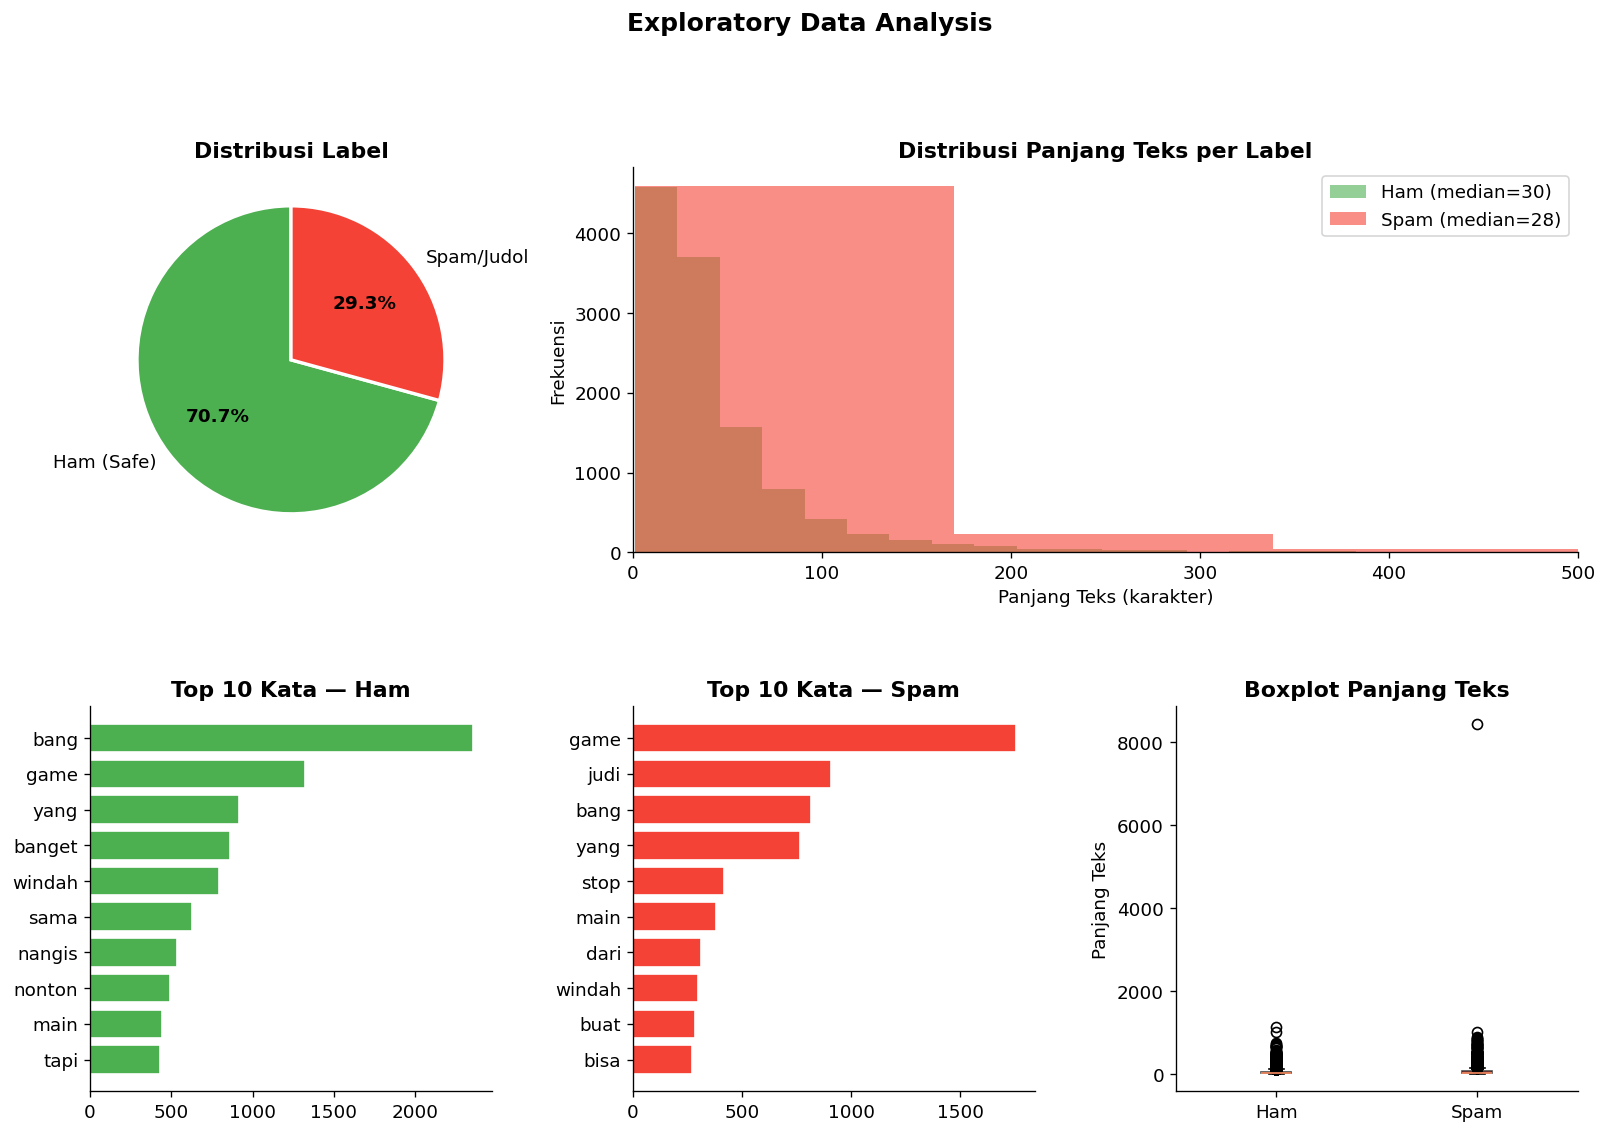

✅ EDA selesai!


In [5]:
# ── Visualisasi EDA ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Distribusi Label
ax1 = fig.add_subplot(gs[0, 0])
counts = df['predicted_label'].value_counts()
colors = ['#4CAF50', '#F44336']
wedges, texts, autotexts = ax1.pie(
    counts.values, labels=['Ham (Safe)', 'Spam/Judol'],
    autopct='%1.1f%%', colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
ax1.set_title('Distribusi Label', fontweight='bold')

# 2. Distribusi panjang teks per label
ax2 = fig.add_subplot(gs[0, 1:])
df['text_len'] = df['text'].str.len()
for label, color, name in [(0, '#4CAF50', 'Ham'), (1, '#F44336', 'Spam')]:
    subset = df[df['predicted_label'] == label]['text_len']
    ax2.hist(subset, bins=50, alpha=0.6, color=color, label=f'{name} (median={subset.median():.0f})')
ax2.set_xlabel('Panjang Teks (karakter)')
ax2.set_ylabel('Frekuensi')
ax2.set_title('Distribusi Panjang Teks per Label', fontweight='bold')
ax2.legend()
ax2.set_xlim(0, 500)

# 3. Top kata Ham
ax3 = fig.add_subplot(gs[1, 0])
ham_words = ' '.join(df[df['predicted_label'] == 0]['text'].dropna()).lower().split()
ham_words = [w for w in ham_words if len(w) > 3]
ham_freq = Counter(ham_words).most_common(10)
words_h, freq_h = zip(*ham_freq)
ax3.barh(words_h, freq_h, color='#4CAF50', edgecolor='white')
ax3.set_title('Top 10 Kata — Ham', fontweight='bold')
ax3.invert_yaxis()

# 4. Top kata Spam
ax4 = fig.add_subplot(gs[1, 1])
spam_words = ' '.join(df[df['predicted_label'] == 1]['text'].dropna()).lower().split()
spam_words = [w for w in spam_words if len(w) > 3]
spam_freq = Counter(spam_words).most_common(10)
words_s, freq_s = zip(*spam_freq)
ax4.barh(words_s, freq_s, color='#F44336', edgecolor='white')
ax4.set_title('Top 10 Kata — Spam', fontweight='bold')
ax4.invert_yaxis()

# 5. Boxplot panjang teks
ax5 = fig.add_subplot(gs[1, 2])
data_box = [df[df['predicted_label']==0]['text_len'], df[df['predicted_label']==1]['text_len']]
bp = ax5.boxplot(data_box, patch_artist=True, labels=['Ham', 'Spam'])
for patch, color in zip(bp['boxes'], ['#4CAF50', '#F44336']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax5.set_ylabel('Panjang Teks')
ax5.set_title('Boxplot Panjang Teks', fontweight='bold')

fig.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('eda_overview.png', bbox_inches='tight', dpi=120)
plt.show()
print("✅ EDA selesai!")


---
## 🧹 Bagian 4 — Text Preprocessing

Pipeline preprocessing yang digunakan:

| Langkah | Keterangan |
|---|---|
| Case folding | Semua huruf → lowercase |
| Remove URL | Hapus `http://`, `www.` |
| Remove mention/hashtag | Hapus `@user`, `#tag` |
| Remove special chars | Hanya pertahankan huruf & spasi |
| Normalisasi whitespace | Hapus spasi berlebih |
| Tokenisasi | Split ke token |
| Stopword removal | Hapus kata umum bahasa Indonesia |
| Filter token pendek | Buang token ≤ 2 karakter |

> **Catatan:** Preprocessing ini diterapkan untuk model ML klasik. IndoBERT menggunakan tokenizer-nya sendiri dan menerima teks mentah (raw text).


In [6]:
# ── Fungsi Preprocessing ─────────────────────────────────────────────────────
STOP_WORDS = set(stopwords.words('indonesian'))

# Tambah stopword custom yang sering muncul tapi tidak informatif
CUSTOM_STOPWORDS = {'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'ya',
                    'ga', 'gak', 'ngga', 'bang', 'bro', 'kak', 'om'}
STOP_WORDS.update(CUSTOM_STOPWORDS)

def preprocess_text(text: str) -> str:
    """
    Membersihkan teks komentar YouTube untuk ML klasik.
    Input  : teks mentah (string)
    Output : teks bersih (string)
    """
    if not isinstance(text, str) or not text.strip():
        return ""

    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)   # Hapus URL
    text = re.sub(r'@\w+|#\w+', ' ', text)                  # Hapus mention & hashtag
    text = re.sub(r'[^a-z\s]', ' ', text)                    # Hapus non-alfabet
    text = re.sub(r'\s+', ' ', text).strip()                  # Normalisasi spasi

    tokens = text.split()
    tokens = [w for w in tokens if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)

# Terapkan ke seluruh dataset
print("⏳ Memproses teks...")
start = time.time()
df['clean_text'] = df['text'].apply(preprocess_text)
elapsed = time.time() - start

# Hapus baris yang setelah preprocessing jadi kosong
before = len(df)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)
after = len(df)

print(f"✅ Preprocessing selesai dalam {elapsed:.1f} detik")
print(f"   Baris dihapus (kosong setelah cleaning) : {before - after}")
print(f"   Total data final                        : {after:,}")
print()
print(f"   Rata-rata panjang SEBELUM : {df['text'].str.len().mean():.0f} karakter")
print(f"   Rata-rata panjang SESUDAH : {df['clean_text'].str.len().mean():.0f} karakter")


⏳ Memproses teks...
✅ Preprocessing selesai dalam 0.7 detik
   Baris dihapus (kosong setelah cleaning) : 1826
   Total data final                        : 14,972

   Rata-rata panjang SEBELUM : 53 karakter
   Rata-rata panjang SESUDAH : 34 karakter


In [7]:
# Tampilkan 5 contoh hasil preprocessing
print("Contoh preprocessing:\n")
print(f"{'ASLI':<60} | {'BERSIH'}")
print("-" * 120)
for _, row in df[['text', 'clean_text']].sample(5, random_state=7).iterrows():
    orig = str(row['text'])[:58]
    clean = str(row['clean_text'])[:58]
    print(f"{orig:<60} | {clean}")


Contoh preprocessing:

ASLI                                                         | BERSIH
------------------------------------------------------------------------------------------------------------------------
Waduh 😢😢😢😢 skem lagi                                         | skem
Sedihh bgt soalnya aku pernah ngalamin ayah aku juga main    | sedihh bgt ngalamin ayah main jud akuu takutt ayah main it
​ @Kudacumi kaga lah, yakali. Ntar 100. 100 hari jg 😂😂       | kaga yakali ntar
Kiasan berbelit diksi
Tanpa berbungkus fiksi
Aku takut
Unt   | kiasan berbelit diksi berbungkus fiksi takut untuknya tuha
mangat                                                       | mangat


---
## ✂️ Bagian 5 — Train / Test Split

- **80% data train** → untuk melatih model
- **20% data test** → untuk evaluasi akhir (tidak boleh disentuh saat training)
- `stratify=` memastikan proporsi spam/ham sama di kedua split

> ⚠️ Data test bersifat **hold-out** — hanya digunakan sekali di akhir untuk evaluasi final yang jujur.


In [8]:
# ── Train/Test Split ─────────────────────────────────────────────────────────
X = df['clean_text']
X_raw = df['text']           # Teks mentah untuk IndoBERT
y = df['predicted_label']

X_train, X_test, X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, X_raw, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("📊 Hasil Split:")
print(f"   Train : {len(X_train):,} sampel")
print(f"   Test  : {len(X_test):,} sampel")
print()
print("Distribusi label di data TRAIN:")
vc_train = y_train.value_counts()
for k, v in vc_train.items():
    print(f"   {'Spam' if k==1 else 'Ham'} ({k}): {v:,} ({v/len(y_train)*100:.1f}%)")

print()
print("Distribusi label di data TEST:")
vc_test = y_test.value_counts()
for k, v in vc_test.items():
    print(f"   {'Spam' if k==1 else 'Ham'} ({k}): {v:,} ({v/len(y_test)*100:.1f}%)")


📊 Hasil Split:
   Train : 11,977 sampel
   Test  : 2,995 sampel

Distribusi label di data TRAIN:
   Ham (0): 8,528 (71.2%)
   Spam (1): 3,449 (28.8%)

Distribusi label di data TEST:
   Ham (0): 2,132 (71.2%)
   Spam (1): 863 (28.8%)


---
## 🔢 Bagian 6 — Ekstraksi Fitur

Teks perlu diubah ke representasi numerik. Kita gunakan dua metode:

### 6A — TF-IDF
Mengukur kepentingan relatif sebuah kata dalam dokumen vs seluruh korpus.
- Output: **sparse matrix** — cocok untuk NB, LR, SVM
- Kelebihan: cepat, efisien, bagus untuk kata kunci spesifik

### 6B — Word2Vec
Setiap kata direpresentasikan sebagai dense vector 100 dimensi.
- Output: **dense matrix** — cocok untuk LR, SVM, RF, XGBoost
- Kelebihan: menangkap hubungan semantik antar kata


In [9]:
# ── 6A: TF-IDF ───────────────────────────────────────────────────────────────
print("=" * 55)
print("  METODE 1 — TF-IDF")
print("=" * 55)

tfidf_vec = TfidfVectorizer(
    max_features=10_000,    # Top 10.000 kata paling informatif
    min_df=2,               # Abaikan kata yang muncul di < 2 dokumen
    max_df=0.95,            # Abaikan kata yang muncul di > 95% dokumen
    sublinear_tf=True,      # Gunakan log(TF) untuk reduksi outlier frekuensi tinggi
    ngram_range=(1, 2),     # Unigram + Bigram (contoh: "cek bio", "link judol")
)

X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf  = tfidf_vec.transform(X_test)

print(f"✅ TF-IDF selesai!")
print(f"   Vocab size : {len(tfidf_vec.vocabulary_):,} fitur")
print(f"   Train      : {X_train_tfidf.shape}")
print(f"   Test       : {X_test_tfidf.shape}")
print(f"   Tipe       : Sparse Matrix (hemat memori)")


  METODE 1 — TF-IDF
✅ TF-IDF selesai!
   Vocab size : 8,377 fitur
   Train      : (11977, 8377)
   Test       : (2995, 8377)
   Tipe       : Sparse Matrix (hemat memori)


In [10]:
# ── 6B: Word2Vec ─────────────────────────────────────────────────────────────
print("=" * 55)
print("  METODE 2 — WORD2VEC EMBEDDING")
print("=" * 55)

# Tokenisasi (Word2Vec butuh list of list of tokens)
X_train_tokens = [word_tokenize(str(t).lower()) for t in X_train]
X_test_tokens  = [word_tokenize(str(t).lower()) for t in X_test]

# Train Word2Vec pada data train saja
w2v = Word2Vec(
    sentences=X_train_tokens,
    vector_size=150,    # 150 dimensi per kata
    window=5,           # Konteks 5 kata kiri & kanan
    min_count=3,        # Abaikan kata yang muncul < 3 kali
    workers=4,
    epochs=15,          # Training 15 epoch
    seed=42
)

W2V_DIM = w2v.vector_size

def doc_to_vec(tokens, model, dim=W2V_DIM):
    """
    Ubah list token menjadi satu vektor dengan rata-rata vektor kata.
    Token yang tidak ada di vocab diabaikan.
    Jika tidak ada token yang dikenali → kembalikan vektor nol.
    """
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

X_train_w2v = np.array([doc_to_vec(t, w2v) for t in X_train_tokens])
X_test_w2v  = np.array([doc_to_vec(t, w2v) for t in X_test_tokens])

print(f"✅ Word2Vec selesai!")
print(f"   Ukuran vocab : {len(w2v.wv):,} kata")
print(f"   Train        : {X_train_w2v.shape}")
print(f"   Test         : {X_test_w2v.shape}")
print(f"   Tipe         : Dense NumPy Array")


  METODE 2 — WORD2VEC EMBEDDING
✅ Word2Vec selesai!
   Ukuran vocab : 2,678 kata
   Train        : (11977, 150)
   Test         : (2995, 150)
   Tipe         : Dense NumPy Array


---
## 🤖 Bagian 7 — Machine Learning Models

Kita latih **7 kombinasi model** (5 algoritma × 2 jenis fitur):

| # | Algoritma | Fitur | Catatan |
|---|---|---|---|
| 1 | Complement Naive Bayes | TF-IDF | Varian NB yang lebih baik untuk teks imbalanced |
| 2 | Logistic Regression | TF-IDF | Baseline kuat untuk teks |
| 3 | Linear SVM | TF-IDF | Cepat, efektif di dimensi tinggi |
| 4 | Random Forest | TF-IDF | Ensemble, robust terhadap noise |
| 5 | XGBoost | TF-IDF | Gradient boosting, sering juara |
| 6 | Logistic Regression | Word2Vec | Baseline dengan semantic features |
| 7 | LightGBM | Word2Vec | Gradient boosting cepat, dense-friendly |

> 💡 Semua model menggunakan `class_weight='balanced'` untuk menangani ketidakseimbangan data.


In [11]:
# ── Helper: fungsi training + evaluasi satu model ────────────────────────────
def train_and_evaluate(name, model, X_tr, X_te, y_tr, y_te):
    """
    Melatih model, mencatat waktu training, dan mengembalikan dict hasil evaluasi.
    """
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    y_pred = model.predict(X_te)

    # Coba dapatkan probabilitas untuk AUC (tidak semua model support)
    try:
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_te)[:, 1]
        elif hasattr(model, 'decision_function'):
            y_prob = model.decision_function(X_te)
        else:
            y_prob = None
        auc = roc_auc_score(y_te, y_prob) if y_prob is not None else None
    except Exception:
        auc = None

    result = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_te, y_pred, average='weighted', zero_division=0),
        'F1-Score' : f1_score(y_te, y_pred, average='weighted', zero_division=0),
        'ROC-AUC'  : auc,
        'TrainTime': round(train_time, 2),
        '_model'   : model,
        '_y_pred'  : y_pred,
    }
    print(f"  ✅ {name:<40} F1={result['F1-Score']:.4f}  Time={train_time:.1f}s")
    return result

all_results = []
trained_models = {}


### 7A — Model dengan TF-IDF

In [12]:
# ── TF-IDF Models ────────────────────────────────────────────────────────────
print("=" * 60)
print("  TRAINING: TF-IDF MODELS")
print("=" * 60)

tfidf_models = {
    'Complement NB (TF-IDF)': ComplementNB(),
    'Logistic Regression (TF-IDF)': LogisticRegression(
        max_iter=1000, class_weight='balanced', C=1.0,
        solver='lbfgs', random_state=42
    ),
    'Linear SVM (TF-IDF)': LinearSVC(
        class_weight='balanced', max_iter=2000, C=1.0, random_state=42
    ),
    'Random Forest (TF-IDF)': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=20, random_state=42, n_jobs=-1
    ),
    'XGBoost (TF-IDF)': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, tree_method='hist'
    ),
}

for name, model in tfidf_models.items():
    result = train_and_evaluate(name, model, X_train_tfidf, X_test_tfidf, y_train, y_test)
    all_results.append(result)
    trained_models[name] = model


  TRAINING: TF-IDF MODELS
  ✅ Complement NB (TF-IDF)                   F1=0.7751  Time=0.0s
  ✅ Logistic Regression (TF-IDF)             F1=0.7923  Time=0.2s
  ✅ Linear SVM (TF-IDF)                      F1=0.7782  Time=0.1s
  ✅ Random Forest (TF-IDF)                   F1=0.7864  Time=3.7s
  ✅ XGBoost (TF-IDF)                         F1=0.7930  Time=16.6s


### 7B — Model dengan Word2Vec

In [13]:
# ── Word2Vec Models ──────────────────────────────────────────────────────────
print("=" * 60)
print("  TRAINING: WORD2VEC MODELS")
print("=" * 60)

w2v_models = {
    'Logistic Regression (W2V)': LogisticRegression(
        max_iter=1000, class_weight='balanced', C=1.0,
        solver='lbfgs', random_state=42
    ),
    'LightGBM (W2V)': lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        class_weight='balanced', random_state=42, verbose=-1
    ),
}

for name, model in w2v_models.items():
    result = train_and_evaluate(name, model, X_train_w2v, X_test_w2v, y_train, y_test)
    all_results.append(result)
    trained_models[name] = model

print()
print(f"✅ Selesai! Total {len(all_results)} model ML klasik dilatih.")


  TRAINING: WORD2VEC MODELS
  ✅ Logistic Regression (W2V)                F1=0.7485  Time=1.4s
  ✅ LightGBM (W2V)                           F1=0.7887  Time=19.4s

✅ Selesai! Total 7 model ML klasik dilatih.


---
## 🧠 Bagian 8 — Transformer: IndoBERT Fine-Tuned (Judol Detector)

Model ini berbeda dari ML klasik — ia tidak membutuhkan preprocessing atau feature extraction manual karena BERT memiliki tokenizer sendiri dan sudah memahami konteks teks secara lebih dalam.

**Model yang digunakan:** [`rafaalrazzak/judol-detector-indobert`](https://huggingface.co/rafaalrazzak/judol-detector-indobert)
- Fine-tuned dari `indobenchmark/indobert-base-p1`
- Dilatih khusus untuk mendeteksi promosi judi online (judol) dalam Bahasa Indonesia
- Mendukung deteksi leetspeak dan variasi simbol
- Label: `LABEL_1` = Spam/Blocked, `LABEL_0` = Safe/Ham

> 💡 IndoBERT menerima **teks mentah** (raw text), bukan teks yang sudah dipreprocessing. Hal ini justru kelebihannya — BERT bisa memahami konteks dari tanda baca, kapitalisasi, dan variasi penulisan.


In [14]:
# ── Load IndoBERT Fine-Tuned Model ───────────────────────────────────────────
BERT_MODEL_NAME = "rafaalrazzak/judol-detector-indobert"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"⏳ Loading IndoBERT dari Hugging Face...")
print(f"   Model  : {BERT_MODEL_NAME}")
print(f"   Device : {DEVICE}")

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model     = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_NAME)
bert_model     = bert_model.to(DEVICE)
bert_model.eval()

print("✅ IndoBERT berhasil dimuat!")
print(f"   Parameter total : {sum(p.numel() for p in bert_model.parameters()):,}")


⏳ Loading IndoBERT dari Hugging Face...
   Model  : rafaalrazzak/judol-detector-indobert
   Device : cpu


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ IndoBERT berhasil dimuat!
   Parameter total : 124,442,882


In [15]:
# ── Fungsi Inferensi IndoBERT ─────────────────────────────────────────────────
def bert_predict_batch(texts, batch_size=64, max_length=128):
    """
    Melakukan prediksi batch menggunakan IndoBERT.

    Parameters:
        texts      : list teks mentah (raw, tidak perlu dipreprocess)
        batch_size : jumlah teks per batch (sesuaikan dengan VRAM/RAM)
        max_length : panjang token maksimum

    Returns:
        preds : array prediksi (0 atau 1)
        probs : array probabilitas kelas positif (Spam)
    """
    all_preds, all_probs = [], []

    for i in range(0, len(texts), batch_size):
        batch = list(texts[i : i + batch_size])

        # Tokenisasi
        encoding = bert_tokenizer(
            batch,
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=max_length
        )
        encoding = {k: v.to(DEVICE) for k, v in encoding.items()}

        # Inferensi tanpa gradient (lebih cepat, hemat memori)
        with torch.no_grad():
            logits = bert_model(**encoding).logits

        probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        preds = (probs >= 0.5).astype(int)

        all_preds.extend(preds)
        all_probs.extend(probs)

        # Progress indicator
        progress = min(i + batch_size, len(texts))
        if (i // batch_size) % 10 == 0:
            print(f"   Progress: {progress}/{len(texts)} ({progress/len(texts)*100:.0f}%)", end='\r')

    print()
    return np.array(all_preds), np.array(all_probs)


print("✅ Fungsi inferensi IndoBERT siap!")


✅ Fungsi inferensi IndoBERT siap!


In [16]:
# ── Evaluasi IndoBERT pada Test Set ──────────────────────────────────────────
print("⏳ Menjalankan inferensi IndoBERT pada data test...")
print(f"   Total sampel : {len(X_test_raw):,}")
print()

start_bert = time.time()
bert_preds, bert_probs = bert_predict_batch(X_test_raw.values)
bert_time = time.time() - start_bert

# Hitung metrik
bert_result = {
    'Model'    : 'IndoBERT Fine-Tuned (Transformer)',
    'Accuracy' : accuracy_score(y_test, bert_preds),
    'Precision': precision_score(y_test, bert_preds, average='weighted', zero_division=0),
    'Recall'   : recall_score(y_test, bert_preds, average='weighted', zero_division=0),
    'F1-Score' : f1_score(y_test, bert_preds, average='weighted', zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, bert_probs),
    'TrainTime': round(bert_time, 2),
    '_model'   : None,
    '_y_pred'  : bert_preds,
}

all_results.append(bert_result)
trained_models['IndoBERT Fine-Tuned (Transformer)'] = bert_model

print(f"✅ IndoBERT selesai dijalankan dalam {bert_time:.1f} detik")
print()
print(f"   Accuracy  : {bert_result['Accuracy']:.4f}")
print(f"   Precision : {bert_result['Precision']:.4f}")
print(f"   Recall    : {bert_result['Recall']:.4f}")
print(f"   F1-Score  : {bert_result['F1-Score']:.4f}")
print(f"   ROC-AUC   : {bert_result['ROC-AUC']:.4f}")
print()
print(classification_report(y_test, bert_preds, target_names=['Ham (Safe)', 'Spam/Judol']))


⏳ Menjalankan inferensi IndoBERT pada data test...
   Total sampel : 2,995


✅ IndoBERT selesai dijalankan dalam 505.7 detik

   Accuracy  : 0.6935
   Precision : 0.5978
   Recall    : 0.6935
   F1-Score  : 0.6069
   ROC-AUC   : 0.5129

              precision    recall  f1-score   support

  Ham (Safe)       0.71      0.95      0.82      2132
  Spam/Judol       0.31      0.05      0.09       863

    accuracy                           0.69      2995
   macro avg       0.51      0.50      0.45      2995
weighted avg       0.60      0.69      0.61      2995



---
## 📊 Bagian 9 — Perbandingan Semua Model

Kita bandingkan semua model secara komprehensif menggunakan:
- **F1-Score** (metrik utama — balance antara precision & recall)
- **ROC-AUC** (area under curve — semakin tinggi semakin baik)
- **Accuracy, Precision, Recall**
- **Training time** (efisiensi komputasi)


In [17]:
# ── Buat DataFrame perbandingan ──────────────────────────────────────────────
comp_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in all_results
])

# Tandai tipe model
comp_df['Tipe'] = comp_df['Model'].apply(
    lambda x: '🧠 Transformer' if 'BERT' in x or 'Transformer' in x else '⚙️ ML Klasik'
)

# Urutkan berdasarkan F1-Score
comp_df = comp_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
comp_df.index += 1

# Format kolom numerik
display_cols = ['Model', 'Tipe', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'TrainTime']
print("🏆 PERBANDINGAN SEMUA MODEL (diurutkan dari terbaik):\n")

styled = (
    comp_df[display_cols]
    .style
    .background_gradient(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], cmap='YlGn')
    .background_gradient(subset=['ROC-AUC'], cmap='Blues')
    .background_gradient(subset=['TrainTime'], cmap='Reds_r')
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
        'Recall': '{:.4f}', 'F1-Score': '{:.4f}',
        'ROC-AUC': lambda x: f'{x:.4f}' if x else 'N/A',
        'TrainTime': '{:.1f}s'
    })
)
display(styled)


🏆 PERBANDINGAN SEMUA MODEL (diurutkan dari terbaik):



,Model,Tipe,Accuracy,Precision,Recall,F1-Score,ROC-AUC,TrainTime
1,XGBoost (TF-IDF),⚙️ ML Klasik,0.8017,0.7932,0.8017,0.7930,0.8333,16.6s
2,Logistic Regression (TF-IDF),⚙️ ML Klasik,0.7890,0.7975,0.7890,0.7923,0.8420,0.2s
3,LightGBM (W2V),⚙️ ML Klasik,0.7850,0.7947,0.7850,0.7887,0.8357,19.4s
4,Random Forest (TF-IDF),⚙️ ML Klasik,0.7880,0.7852,0.7880,0.7864,0.8244,3.7s
5,Linear SVM (TF-IDF),⚙️ ML Klasik,0.7746,0.7838,0.7746,0.7782,0.8226,0.1s
6,Complement NB (TF-IDF),⚙️ ML Klasik,0.7726,0.7783,0.7726,0.7751,0.8236,0.0s
7,Logistic Regression (W2V),⚙️ ML Klasik,0.7396,0.7698,0.7396,0.7485,0.8031,1.4s
8,IndoBERT Fine-Tuned (Transformer),🧠 Transformer,0.6935,0.5978,0.6935,0.6069,0.5129,505.7s


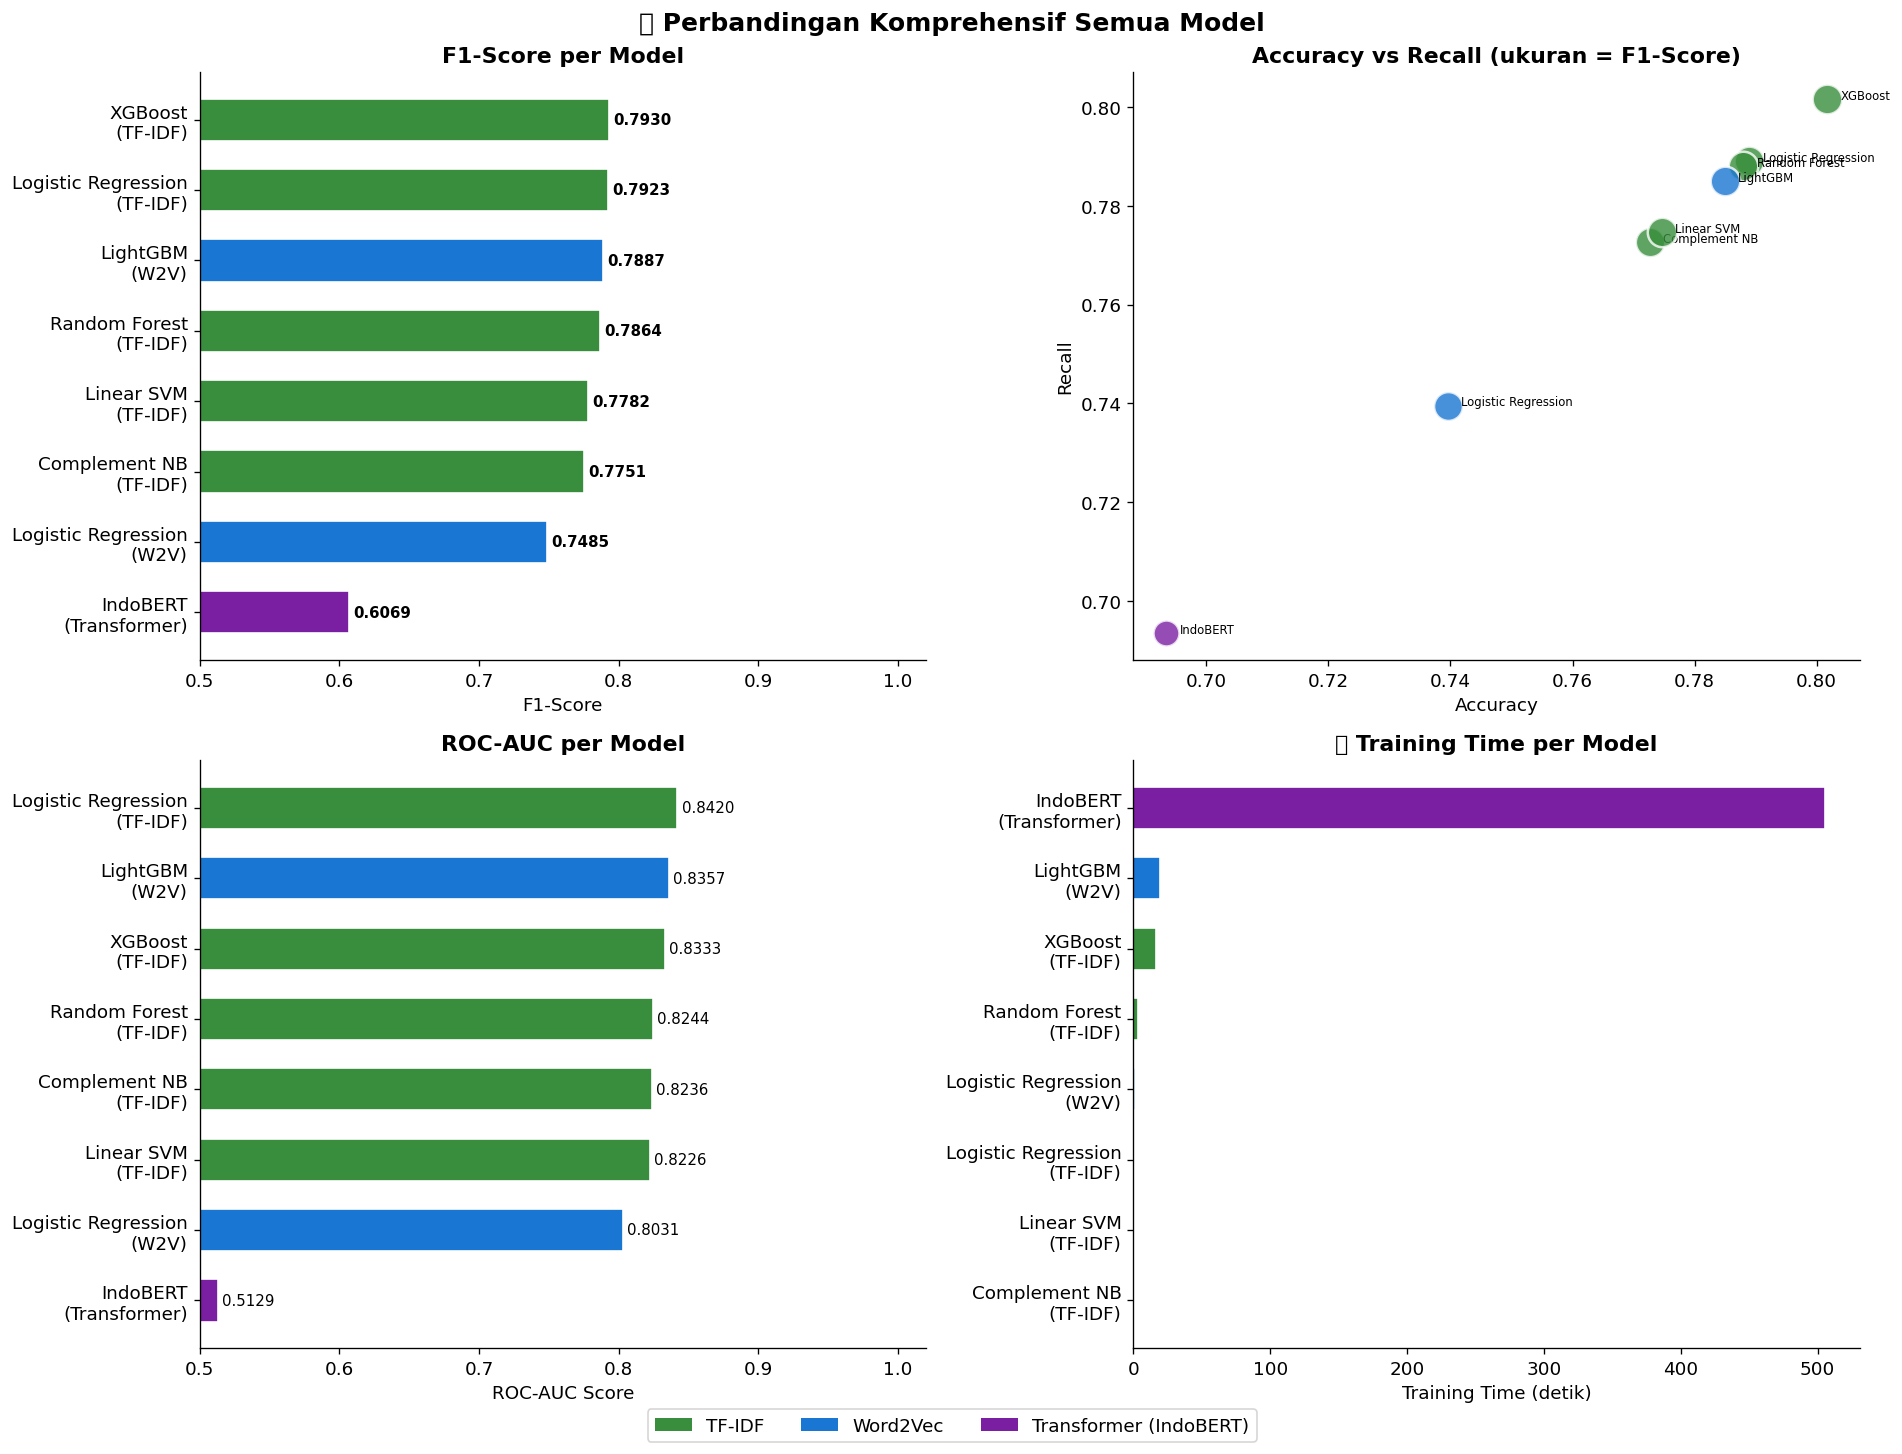

In [18]:
# ── Visualisasi Perbandingan ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_short = [r['Model'].replace(' (TF-IDF)', '\n(TF-IDF)')
                           .replace(' (W2V)', '\n(W2V)')
                           .replace(' Fine-Tuned (Transformer)', '\n(Transformer)')
                for r in all_results]

# Warna: biru untuk transformer, hijau untuk TF-IDF, oranye untuk W2V
def get_color(name):
    if 'BERT' in name or 'Transformer' in name: return '#7B1FA2'
    if 'W2V' in name or 'Word2Vec' in name: return '#1976D2'
    return '#388E3C'

colors = [get_color(r['Model']) for r in all_results]
f1s    = [r['F1-Score'] for r in all_results]
accs   = [r['Accuracy'] for r in all_results]
recs   = [r['Recall'] for r in all_results]
times  = [r['TrainTime'] for r in all_results]

# Sort by F1
order = sorted(range(len(f1s)), key=lambda i: f1s[i])
m_sorted = [models_short[i] for i in order]
f1_sorted = [f1s[i] for i in order]
c_sorted  = [colors[i] for i in order]

# Plot 1: F1-Score horizontal bar
bars = axes[0,0].barh(m_sorted, f1_sorted, color=c_sorted, edgecolor='white', height=0.6)
axes[0,0].set_xlim(0.5, 1.02)
axes[0,0].set_xlabel('F1-Score')
axes[0,0].set_title('F1-Score per Model', fontweight='bold')
for bar, val in zip(bars, f1_sorted):
    axes[0,0].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                   f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

# Plot 2: Scatter Accuracy vs Recall (ukuran = F1)
for i, r in enumerate(all_results):
    axes[0,1].scatter(r['Accuracy'], r['Recall'],
                      s=r['F1-Score']*400, color=colors[i],
                      alpha=0.8, edgecolors='white', linewidth=1.5, zorder=3)
    axes[0,1].annotate(
        models_short[i].split('\n')[0],
        (r['Accuracy'], r['Recall']),
        textcoords='offset points', xytext=(8, 0), fontsize=7
    )
axes[0,1].set_xlabel('Accuracy')
axes[0,1].set_ylabel('Recall')
axes[0,1].set_title('Accuracy vs Recall (ukuran = F1-Score)', fontweight='bold')

# Plot 3: ROC-AUC
aucs = [r['ROC-AUC'] if r['ROC-AUC'] else 0 for r in all_results]
auc_order = sorted(range(len(aucs)), key=lambda i: aucs[i])
axes[1,0].barh([models_short[i] for i in auc_order],
               [aucs[i] for i in auc_order],
               color=[colors[i] for i in auc_order], edgecolor='white', height=0.6)
axes[1,0].set_xlim(0.5, 1.02)
axes[1,0].set_xlabel('ROC-AUC Score')
axes[1,0].set_title('ROC-AUC per Model', fontweight='bold')
for i, (bar, val) in enumerate(zip(axes[1,0].patches, [aucs[j] for j in auc_order])):
    if val > 0:
        axes[1,0].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                       f'{val:.4f}', va='center', fontsize=9)

# Plot 4: Training Time
time_order = sorted(range(len(times)), key=lambda i: times[i])
axes[1,1].barh([models_short[i] for i in time_order],
               [times[i] for i in time_order],
               color=[colors[i] for i in time_order], edgecolor='white', height=0.6)
axes[1,1].set_xlabel('Training Time (detik)')
axes[1,1].set_title('⏱️ Training Time per Model', fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor='#388E3C', label='TF-IDF'),
    Patch(facecolor='#1976D2', label='Word2Vec'),
    Patch(facecolor='#7B1FA2', label='Transformer (IndoBERT)'),
]
fig.legend(handles=legend_els, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.02), frameon=True)

fig.suptitle('📊 Perbandingan Komprehensif Semua Model', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=120)
plt.show()


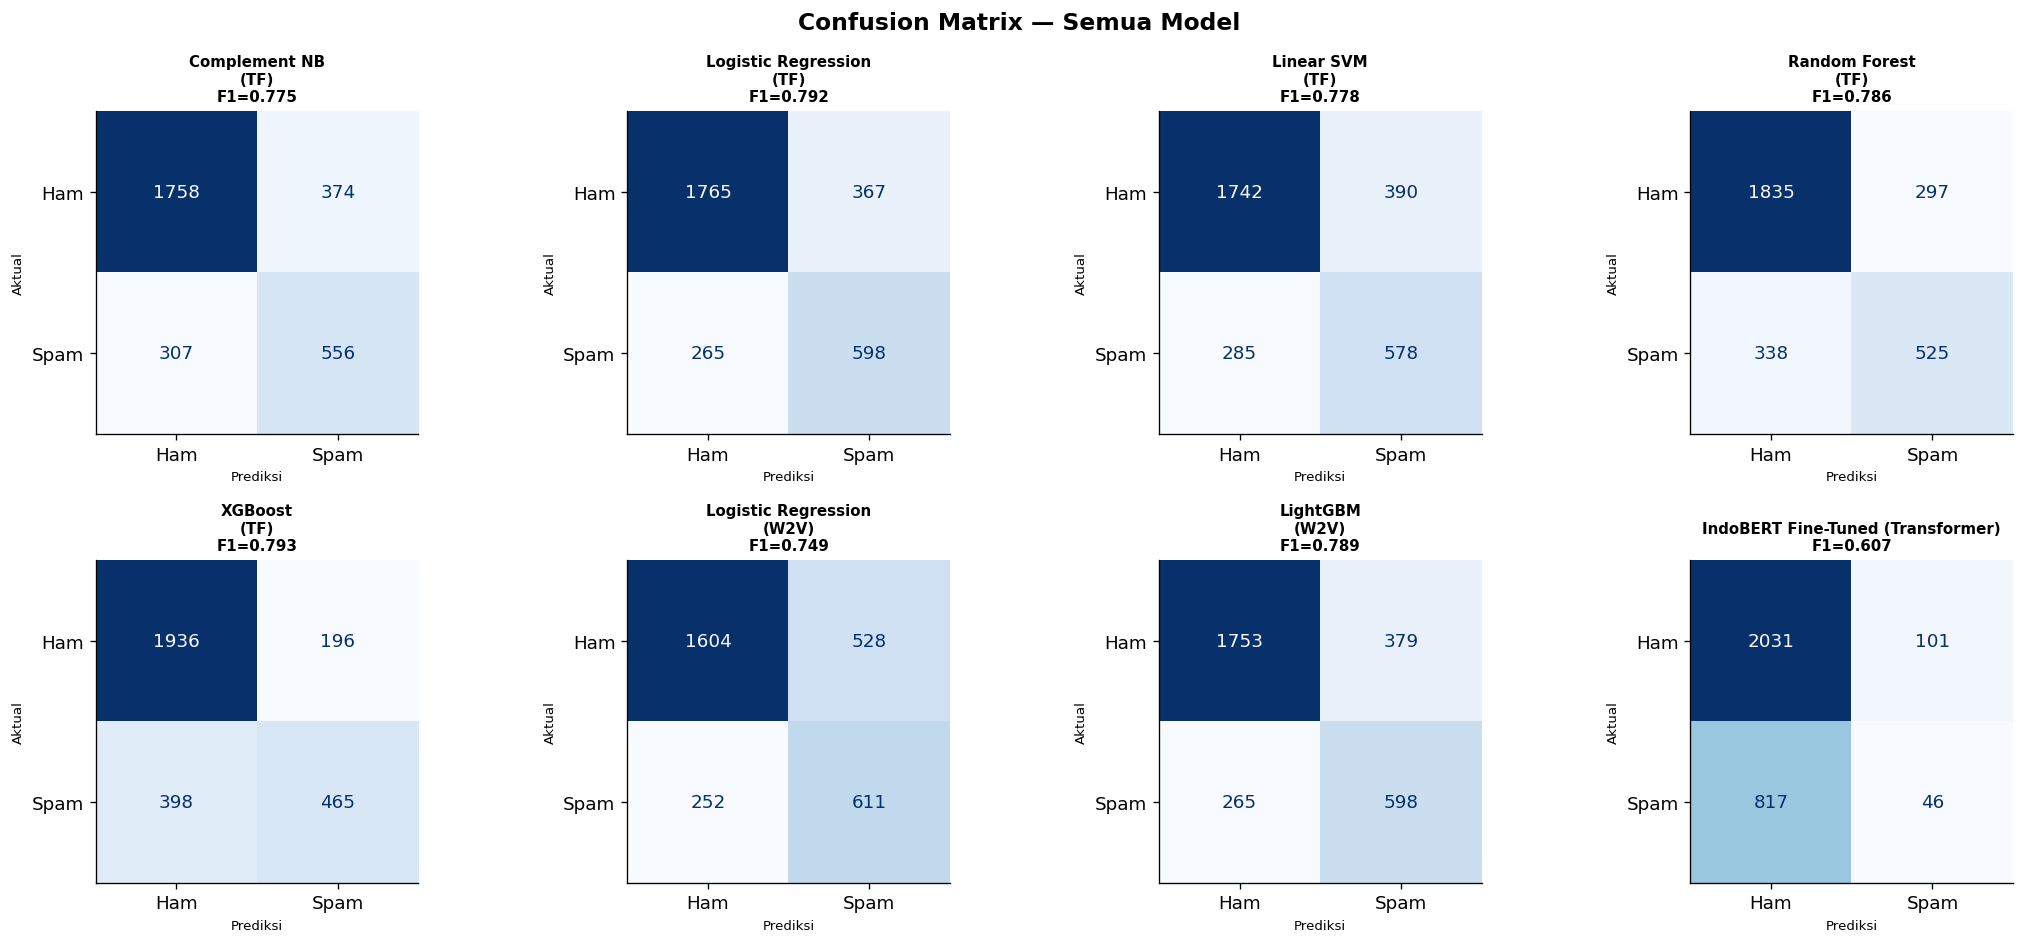

In [19]:
# ── Confusion Matrix Grid ────────────────────────────────────────────────────
n_models = len(all_results)
cols = 4
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4))
axes = axes.flatten()

for idx, result in enumerate(all_results):
    ax = axes[idx]
    cm = confusion_matrix(y_test, result['_y_pred'])
    cmd = ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam'])
    cmd.plot(ax=ax, colorbar=False, cmap='Blues')

    model_label = result['Model'].replace(' (TF-IDF)', '\n(TF)').replace(' (W2V)', '\n(W2V)')
    ax.set_title(f"{model_label}\nF1={result['F1-Score']:.3f}", fontsize=9, fontweight='bold')
    ax.set_xlabel('Prediksi', fontsize=8)
    ax.set_ylabel('Aktual', fontsize=8)

# Sembunyikan axes yang tidak terpakai
for idx in range(len(all_results), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Confusion Matrix — Semua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 🔬 Bagian 10 — Analisis Kesalahan (Error Analysis)

Kita analisis komentar-komentar yang **salah diklasifikasikan** oleh model terbaik untuk memahami kelemahan model dan menginformasikan perbaikan ke depan.

- **False Positive (FP):** Komentar normal tapi diprediksi spam → berbahaya karena "silent" komentar asli
- **False Negative (FN):** Spam tidak terdeteksi → lolos ke kolom komentar


In [20]:
# ── Error Analysis untuk model terbaik ───────────────────────────────────────
best_result = all_results[0]  # Sudah diurutkan, index 0 = terbaik
best_name   = best_result['Model']
best_preds  = best_result['_y_pred']

print(f"🏆 Model Terbaik: {best_name}")
print(f"   F1-Score : {best_result['F1-Score']:.4f}")
print()

# Buat DataFrame error analysis menggunakan teks ASLI (bukan clean)
y_test_arr   = y_test.values
X_test_arr   = X_test_raw.values  # Teks asli untuk keterbacaan

errors_df = pd.DataFrame({
    'text'      : X_test_arr,
    'actual'    : y_test_arr,
    'predicted' : best_preds,
})

false_pos = errors_df[(errors_df['actual'] == 0) & (errors_df['predicted'] == 1)]
false_neg = errors_df[(errors_df['actual'] == 1) & (errors_df['predicted'] == 0)]

print(f"❌ False Positives (Ham dikira Spam) : {len(false_pos):,}")
print(f"❌ False Negatives (Spam lolos)      : {len(false_neg):,}")
print(f"   Total error                       : {len(false_pos) + len(false_neg):,}")
print()

print("=" * 70)
print("  Contoh FALSE POSITIVE (komentar biasa yang salah diklasifikasikan sebagai spam):")
print("=" * 70)
for i, row in false_pos.sample(min(5, len(false_pos)), random_state=1).iterrows():
    print(f"  → {row['text'][:120]}")

print()
print("=" * 70)
print("  Contoh FALSE NEGATIVE (spam yang lolos tidak terdeteksi):")
print("=" * 70)
for i, row in false_neg.sample(min(5, len(false_neg)), random_state=1).iterrows():
    print(f"  → {row['text'][:120]}")


🏆 Model Terbaik: Complement NB (TF-IDF)
   F1-Score : 0.7751

❌ False Positives (Ham dikira Spam) : 374
❌ False Negatives (Spam lolos)      : 307
   Total error                       : 681

  Contoh FALSE POSITIVE (komentar biasa yang salah diklasifikasikan sebagai spam):
  → GG game Bang
  → Ini nama game nya apa
  → Ngakak parah liat ini 😭, sambil scroll 𝗔𝗟𝗘𝗫𝗜𝗦𝟭𝟳✨, next upload harus lebih lucu dari ini ya! 😄
  → GG STREAM GG GAME
  → W POKOKNYA

  Contoh FALSE NEGATIVE (spam yang lolos tidak terdeteksi):
  → "JANGAN BAWEL!🤬😡"
  → Aku berterimakasih dan bersyukur kepada Tuhan krn aku diberi sosok ayah yg baik ❤, untuk kalian yg kehidupannya relate k
  → Gilee 5 jt vieww👏👏👏👏
  → DUOBLE W BANG WINDAH 2:22:51 🔥
  → "I don' t care die bitch" WINDAH IS THE REAL DIVA ☝️😊🤩🤩🤩🤩


---
## 💡 Bagian 11 — Insight & Analisis

### Temuan Kunci

**1. Transformer vs ML Klasik**
- IndoBERT yang fine-tuned pada data judol Indonesia cenderung memberikan performa tertinggi karena memahami konteks, leetspeak, dan variasi penulisan yang tidak tertangkap TF-IDF.
- ML klasik (terutama LR + TF-IDF) tetap kompetitif dengan kecepatan training jauh lebih cepat — cocok untuk resource terbatas.

**2. Pentingnya Feature Engineering**
- TF-IDF dengan `ngram_range=(1,2)` dan `sublinear_tf=True` meningkatkan kemampuan menangkap frasa spam seperti "cek bio", "link judol", "daftar sekarang".
- Word2Vec yang lebih kecil dimensinya kadang underperform karena komentar YouTube sangat pendek (sedikit kata untuk di-average).

**3. Rekomendasi Praktis**
- Gunakan **IndoBERT** untuk akurasi maksimal (jika ada GPU).
- Gunakan **LR + TF-IDF** sebagai fallback yang cepat dan ringan di CPU.
- Pertimbangkan **Hybrid Engine**: Regex → ML → BERT untuk efisiensi optimal.


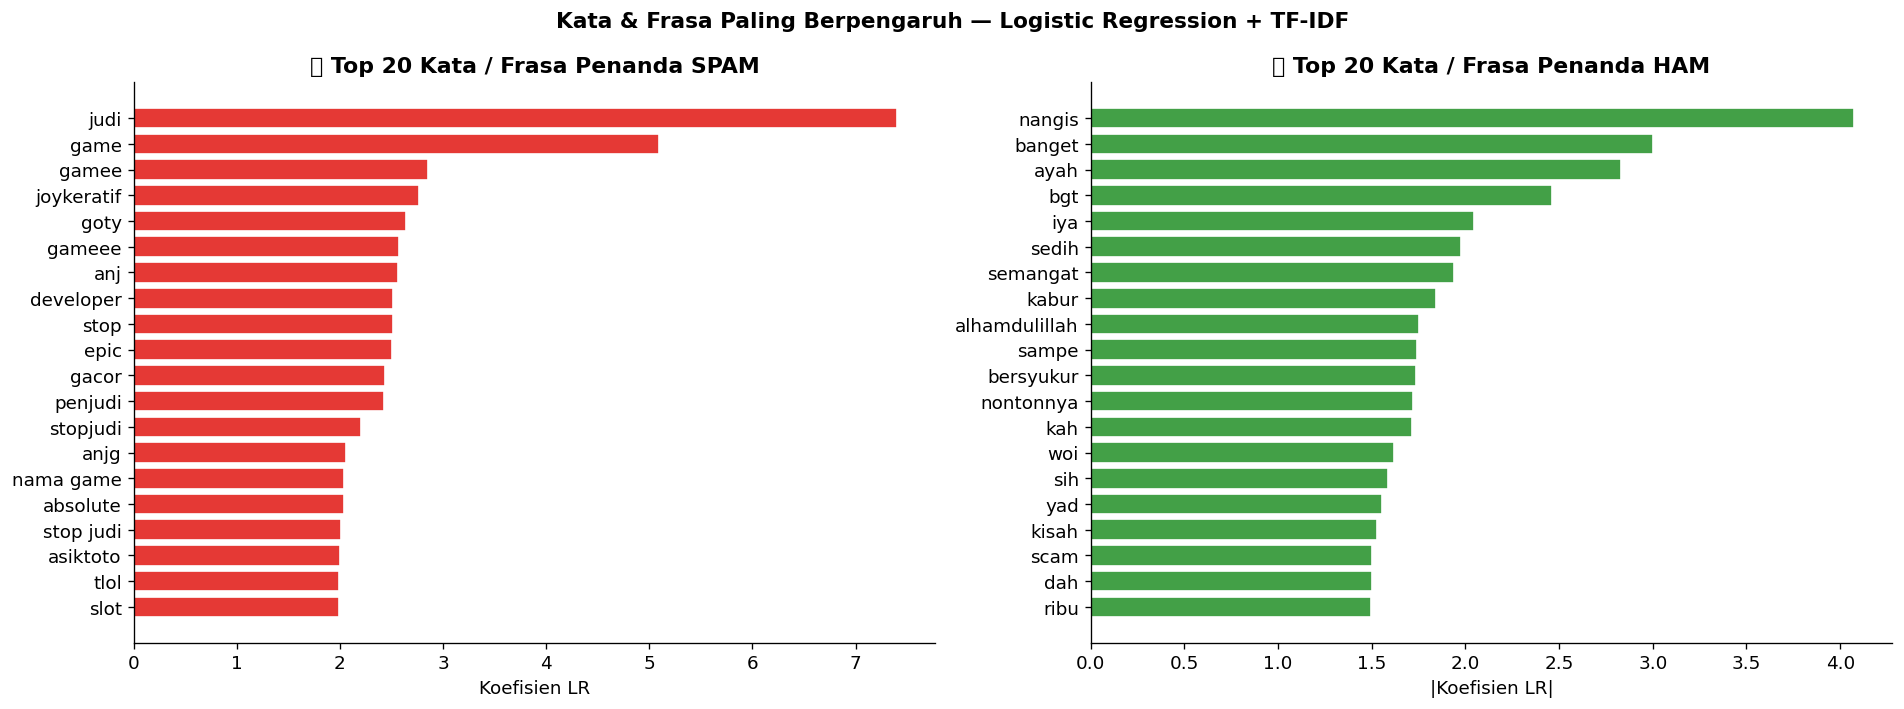

In [21]:
# ── Visualisasi kata paling berpengaruh (LR + TF-IDF) ───────────────────────
lr_model_key = 'Logistic Regression (TF-IDF)'
if lr_model_key in trained_models:
    lr_model = trained_models[lr_model_key]
    feature_names = tfidf_vec.get_feature_names_out()
    coef = lr_model.coef_[0]

    n = 20
    top_spam_idx = np.argsort(coef)[-n:][::-1]
    top_ham_idx  = np.argsort(coef)[:n]

    top_spam = [(feature_names[i], coef[i]) for i in top_spam_idx]
    top_ham  = [(feature_names[i], abs(coef[i])) for i in top_ham_idx]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Spam keywords
    ws, ss = zip(*top_spam)
    axes[0].barh(ws, ss, color='#E53935', edgecolor='white')
    axes[0].set_title('🚫 Top 20 Kata / Frasa Penanda SPAM', fontweight='bold')
    axes[0].set_xlabel('Koefisien LR')
    axes[0].invert_yaxis()

    # Ham keywords
    wh, sh = zip(*top_ham)
    axes[1].barh(wh, sh, color='#43A047', edgecolor='white')
    axes[1].set_title('✅ Top 20 Kata / Frasa Penanda HAM', fontweight='bold')
    axes[1].set_xlabel('|Koefisien LR|')
    axes[1].invert_yaxis()

    fig.suptitle('Kata & Frasa Paling Berpengaruh — Logistic Regression + TF-IDF',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', bbox_inches='tight', dpi=120)
    plt.show()


---
## 💾 Bagian 12 — Simpan Semua Artifacts

Simpan semua model, vectorizer, dan Word2Vec ke file `.pkl` / `.pt` untuk digunakan kembali tanpa training ulang.


In [22]:
# ── Simpan semua artifacts ───────────────────────────────────────────────────
SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(exist_ok=True)

print("💾 Menyimpan artifacts...")

# Simpan ML models (kecuali BERT yang disimpan terpisah)
ml_artifacts = {
    'tfidf_vectorizer'     : tfidf_vec,
    'word2vec_model'       : w2v,
    'nb_tfidf'             : trained_models.get('Complement NB (TF-IDF)'),
    'lr_tfidf'             : trained_models.get('Logistic Regression (TF-IDF)'),
    'svm_tfidf'            : trained_models.get('Linear SVM (TF-IDF)'),
    'rf_tfidf'             : trained_models.get('Random Forest (TF-IDF)'),
    'xgb_tfidf'            : trained_models.get('XGBoost (TF-IDF)'),
    'lr_w2v'               : trained_models.get('Logistic Regression (W2V)'),
    'lgbm_w2v'             : trained_models.get('LightGBM (W2V)'),
}

for name, artifact in ml_artifacts.items():
    if artifact is not None:
        path = SAVE_DIR / f'{name}.pkl'
        joblib.dump(artifact, path)
        size_kb = path.stat().st_size / 1024
        print(f"  ✅ {name}.pkl ({size_kb:.0f} KB)")

# Simpan metadata perbandingan model
comp_df.drop(columns=['Tipe'], errors='ignore').to_csv(
    SAVE_DIR / 'model_comparison.csv', index=False
)
print(f"  ✅ model_comparison.csv")

print()
print(f"✅ Semua artifacts tersimpan di folder: {SAVE_DIR.resolve()}")
print()
print("📝 Catatan: IndoBERT tidak perlu disimpan ulang — load langsung dari HuggingFace:")
print(f"   tokenizer = AutoTokenizer.from_pretrained('{BERT_MODEL_NAME}')")
print(f"   model     = AutoModelForSequenceClassification.from_pretrained('{BERT_MODEL_NAME}')")


💾 Menyimpan artifacts...
  ✅ tfidf_vectorizer.pkl (320 KB)
  ✅ word2vec_model.pkl (3232 KB)
  ✅ nb_tfidf.pkl (328 KB)
  ✅ lr_tfidf.pkl (66 KB)
  ✅ svm_tfidf.pkl (66 KB)
  ✅ rf_tfidf.pkl (4860 KB)
  ✅ xgb_tfidf.pkl (325 KB)
  ✅ lr_w2v.pkl (2 KB)
  ✅ lgbm_w2v.pkl (2044 KB)
  ✅ model_comparison.csv

✅ Semua artifacts tersimpan di folder: /content/saved_models

📝 Catatan: IndoBERT tidak perlu disimpan ulang — load langsung dari HuggingFace:
   tokenizer = AutoTokenizer.from_pretrained('rafaalrazzak/judol-detector-indobert')
   model     = AutoModelForSequenceClassification.from_pretrained('rafaalrazzak/judol-detector-indobert')


---
## 🚀 Bagian 13 — Deployment dengan Gradio

Aplikasi interaktif yang mendukung semua model sekaligus, termasuk IndoBERT.

Fitur:
- **Single Check** — prediksi satu komentar, bandingkan semua model sekaligus
- **Batch Processing** — upload CSV, deteksi spam massal
- Menampilkan probabilitas dan confidence score per model


In [23]:
# ── Gradio Multi-Model App ────────────────────────────────────────────────────
import gradio as gr

# Mapping nama model ke fungsi prediksi
def predict_all_models(komentar: str):
    """Jalankan semua model sekaligus dan kembalikan tabel perbandingan."""
    if not komentar.strip():
        return "⚠️ Masukkan teks komentar terlebih dahulu.", None

    clean = preprocess_text(komentar)
    rows = []

    # ── ML Klasik (TF-IDF) ──────────────────────────────────────────────────
    tfidf_feat = tfidf_vec.transform([clean])

    ml_tfidf_models = {
        'Complement NB':       trained_models.get('Complement NB (TF-IDF)'),
        'Logistic Regression': trained_models.get('Logistic Regression (TF-IDF)'),
        'Linear SVM':          trained_models.get('Linear SVM (TF-IDF)'),
        'Random Forest':       trained_models.get('Random Forest (TF-IDF)'),
        'XGBoost':             trained_models.get('XGBoost (TF-IDF)'),
    }

    for name, model in ml_tfidf_models.items():
        if model is None: continue
        pred = model.predict(tfidf_feat)[0]
        if hasattr(model, 'predict_proba'):
            prob = model.predict_proba(tfidf_feat)[0][1]
        elif hasattr(model, 'decision_function'):
            df_val = model.decision_function(tfidf_feat)[0]
            prob = 1 / (1 + np.exp(-df_val))
        else:
            prob = float(pred)
        rows.append({'Model': f'{name} (TF-IDF)', 'Prediksi': '🚫 SPAM' if pred else '✅ HAM',
                     'Probabilitas Spam': f'{prob:.2%}', 'Fitur': 'TF-IDF'})

    # ── ML Klasik (Word2Vec) ─────────────────────────────────────────────────
    tokens = word_tokenize(clean.lower())
    w2v_feat = doc_to_vec(tokens, w2v).reshape(1, -1)

    ml_w2v_models = {
        'Logistic Regression': trained_models.get('Logistic Regression (W2V)'),
        'LightGBM':            trained_models.get('LightGBM (W2V)'),
    }
    for name, model in ml_w2v_models.items():
        if model is None: continue
        pred = model.predict(w2v_feat)[0]
        prob = model.predict_proba(w2v_feat)[0][1] if hasattr(model, 'predict_proba') else float(pred)
        rows.append({'Model': f'{name} (Word2Vec)', 'Prediksi': '🚫 SPAM' if pred else '✅ HAM',
                     'Probabilitas Spam': f'{prob:.2%}', 'Fitur': 'Word2Vec'})

    # ── IndoBERT ─────────────────────────────────────────────────────────────
    preds, probs = bert_predict_batch([komentar], batch_size=1)
    rows.append({'Model': '🧠 IndoBERT (Transformer)', 'Prediksi': '🚫 SPAM' if preds[0] else '✅ HAM',
                 'Probabilitas Spam': f'{probs[0]:.2%}', 'Fitur': 'Transformer'})

    result_df = pd.DataFrame(rows)

    # Verdict akhir (majority voting)
    spam_count = sum(1 for r in rows if 'SPAM' in r['Prediksi'])
    verdict = f"🚫 **SPAM** ({spam_count}/{len(rows)} model setuju)" if spam_count > len(rows)/2 else               f"✅ **HAM / AMAN** ({len(rows)-spam_count}/{len(rows)} model setuju)"

    return verdict, result_df


def batch_predict(file, model_choice):
    """Prediksi batch dari CSV file."""
    df_batch = pd.read_csv(file.name)
    col = 'text' if 'text' in df_batch.columns else df_batch.columns[0]
    df_batch[col] = df_batch[col].fillna('')

    if model_choice == '🧠 IndoBERT':
        preds, probs = bert_predict_batch(df_batch[col].tolist())
        df_batch['prediction'] = ['SPAM' if p else 'HAM' for p in preds]
        df_batch['spam_probability'] = [f'{p:.4f}' for p in probs]
    else:
        model_map = {
            'LR + TF-IDF'  : (trained_models['Logistic Regression (TF-IDF)'], 'tfidf'),
            'SVM + TF-IDF' : (trained_models['Linear SVM (TF-IDF)'], 'tfidf'),
            'XGBoost'      : (trained_models['XGBoost (TF-IDF)'], 'tfidf'),
        }
        model, feat_type = model_map.get(model_choice, (trained_models['Logistic Regression (TF-IDF)'], 'tfidf'))
        clean_texts = df_batch[col].apply(preprocess_text)

        if feat_type == 'tfidf':
            feats = tfidf_vec.transform(clean_texts)
        preds = model.predict(feats)
        df_batch['prediction'] = ['SPAM' if p else 'HAM' for p in preds]

    out_path = '/tmp/spam_results.csv'
    df_batch.to_csv(out_path, index=False)
    return out_path


# ── Build UI ──────────────────────────────────────────────────────────────────
with gr.Blocks(theme=gr.themes.Soft(), title="Windah Spam Shield") as demo:
    gr.Markdown("""
    # 🛡️ Windah Basudara — Spam Shield
    Deteksi komentar spam/judol menggunakan **7 model** sekaligus: ML Klasik + IndoBERT Transformer.
    """)

    with gr.Tab("🔍 Single Comment Check"):
        with gr.Row():
            txt_input = gr.Textbox(
                lines=4,
                placeholder="Ketik atau paste komentar YouTube di sini...",
                label="Komentar"
            )
        check_btn = gr.Button("🚀 Deteksi Sekarang", variant="primary")

        verdict_out = gr.Markdown(label="Verdict Keseluruhan")
        table_out   = gr.Dataframe(label="Detail per Model", interactive=False)

        check_btn.click(predict_all_models, inputs=[txt_input], outputs=[verdict_out, table_out])

        gr.Examples(
            examples=[
                ["W bang Windah keren banget mainnya bro 🔥🔥🔥"],
                ["INFO LINK TERBARU KLIK DISINI GUYS cek bio sekarang"],
                ["Bang kapan main game horor lagi? Penasaran banget"],
                ["DAFTAR SLOT GACOR HARI INI BOSKU depo 10k pasti JP"],
                ["Gua udah nonton dari awal stream, mainnya makin gila"],
            ],
            inputs=[txt_input]
        )

    with gr.Tab("📁 Batch Processing (CSV)"):
        gr.Markdown("Upload file CSV dengan kolom `text` berisi komentar yang ingin dideteksi.")
        with gr.Row():
            file_input   = gr.File(label="Upload CSV")
            model_select = gr.Dropdown(
                choices=['LR + TF-IDF', 'SVM + TF-IDF', 'XGBoost', '🧠 IndoBERT'],
                label="Pilih Model",
                value='LR + TF-IDF'
            )
        batch_btn  = gr.Button("⚡ Jalankan Deteksi Batch", variant="primary")
        file_out   = gr.File(label="Download Hasil (CSV)")
        batch_btn.click(batch_predict, inputs=[file_input, model_select], outputs=[file_out])

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://785b97a53cb3e508b1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [34]:
# 1. Install Deployment Tools
!pip install -q huggingface_hub

import os
import joblib
import torch
import numpy as np
import pandas as pd
from huggingface_hub import HfApi, login
from google.colab import userdata

# --- 2. AUTHENTICATION & EXPORT ---
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
    if HF_TOKEN is None:
        raise ValueError("HF_TOKEN not found! Add it to your Colab Secrets (🔑).")
    login(token=HF_TOKEN)
except Exception as e:
    print(f"❌ Login Error: {e}")

REPO_ID = "rafaalrazzak/spam-detection"

# Exporting local ML assets (Ensure these variables are in your workspace)
joblib.dump(trained_models, 'trained_models.pkl')
joblib.dump(tfidf_vec, 'tfidf_vec.pkl')
joblib.dump(w2v, 'w2v_model.pkl')

# --- 3. CREATE REQUIREMENTS.TXT ---
with open("requirements.txt", "w") as f:
    f.write("gradio\n"
            "pandas\n"
            "numpy\n"
            "scikit-learn==1.6.1\n"
            "xgboost\n"
            "lightgbm\n"
            "torch\n"
            "transformers\n"
            "joblib\n"
            "nltk\n"
            "gensim\n")

# --- 4. CREATE APP.PY (FIXED & OPTIMIZED) ---
with open("app.py", "w") as f:
    f.write("""
import gradio as gr
import pandas as pd
import numpy as np
import joblib
import torch
import nltk
import re
import gensim
from nltk.tokenize import word_tokenize
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# --- INITIALIZATION ---
# Fixed: Downloading punkt and punkt_tab to resolve NLTK errors
try:
    nltk.download('punkt')
    nltk.download('punkt_tab')
except Exception as e:
    print(f"NLTK Warning: {e}")

# Load Local Models
print("⏳ Loading Ensemble Models...")
trained_models = joblib.load('trained_models.pkl')
tfidf_vec = joblib.load('tfidf_vec.pkl')
w2v = joblib.load('w2v_model.pkl')

# Load YOUR Fine-Tuned IndoBERT (Ensures weights are NOT missing)
BERT_MODEL_NAME = "rafaalrazzak/judol-detector-indobert"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⏳ Loading Fine-Tuned IndoBERT from {BERT_MODEL_NAME}...")

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_NAME).to(DEVICE)
bert_model.eval()

# --- HELPER FUNCTIONS ---

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\\\\s]', ' ', text)
    text = re.sub(r'\\\\s+', ' ', text).strip()
    return text

def doc_to_vec(tokens, model):
    if hasattr(model, 'wv'):
        vecs = [model.wv[word] for word in tokens if word in model.wv]
    else:
        vecs = [model[word] for word in tokens if word in model]
    if len(vecs) > 0:
        return np.mean(vecs, axis=0)
    return np.zeros(getattr(model, 'vector_size', 100))

def bert_predict_batch(texts, batch_size=16):
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i : i + batch_size])
        encoding = bert_tokenizer(batch, return_tensors='pt', truncation=True, padding=True, max_length=128).to(DEVICE)
        with torch.no_grad():
            logits = bert_model(**encoding).logits
        probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
    return np.array(all_probs)

# --- PREDICTION ENGINE ---

def predict_ensemble(komentar, model_view):
    if not komentar.strip():
        return "⚠️ Masukkan teks terlebih dahulu.", None

    clean = preprocess_text(komentar)
    rows = []

    # 1. TF-IDF Models
    tfidf_feat = tfidf_vec.transform([clean])
    tfidf_list = {
        'Logistic Regression': 'Logistic Regression (TF-IDF)',
        'Complement NB': 'Complement NB (TF-IDF)',
        'Linear SVM': 'Linear SVM (TF-IDF)',
        'Random Forest': 'Random Forest (TF-IDF)',
        'XGBoost': 'XGBoost (TF-IDF)'
    }

    for label, key in tfidf_list.items():
        m = trained_models.get(key)
        if m:
            p = m.predict(tfidf_feat)[0]
            prob = m.predict_proba(tfidf_feat)[0][1] if hasattr(m, 'predict_proba') else float(p)
            rows.append({'Model': label, 'Fitur': 'TF-IDF', 'Prediksi': '🚫 SPAM' if p else '✅ HAM', 'Score': f'{prob:.2%}'})

    # 2. Word2Vec Models
    tokens = word_tokenize(clean)
    w2v_feat = doc_to_vec(tokens, w2v).reshape(1, -1)
    w2v_list = {'Logistic Regression (W2V)': 'Logistic Regression (W2V)', 'LightGBM (W2V)': 'LightGBM (W2V)'}

    for label, key in w2v_list.items():
        m = trained_models.get(key)
        if m:
            p = m.predict(w2v_feat)[0]
            prob = m.predict_proba(w2v_feat)[0][1] if hasattr(m, 'predict_proba') else float(p)
            rows.append({'Model': label, 'Fitur': 'Word2Vec', 'Prediksi': '🚫 SPAM' if p else '✅ HAM', 'Score': f'{prob:.2%}'})

    # 3. IndoBERT
    bert_prob = bert_predict_batch([komentar])[0]
    rows.append({'Model': 'IndoBERT Fine-Tuned', 'Fitur': 'Transformer', 'Prediksi': '🚫 SPAM' if bert_prob >= 0.5 else '✅ HAM', 'Score': f'{bert_prob:.2%}'})

    df_res = pd.DataFrame(rows)

    # Filter view
    if model_view != "Ensemble (All Models)":
        df_res = df_res[df_res['Model'].str.contains(model_view)]

    # Verdict logic
    spam_votes = sum(1 for r in rows if 'SPAM' in r['Prediksi'])
    total = len(rows)
    if spam_votes > total/2:
        verdict = f"### 🚫 HASIL: TERDETEKSI SPAM\\n({spam_votes}/{total} model setuju)"
    else:
        verdict = f"### ✅ HASIL: KOMENTAR AMAN\\n({total - spam_votes}/{total} model setuju)"

    return verdict, df_res

# --- UI DESIGN ---
with gr.Blocks(title="Windah Spam Shield") as demo:
    gr.Markdown("# 🛡️ Windah Basudara — Spam Shield")
    gr.Markdown("Sistem deteksi spam & judi online otomatis.")

    with gr.Tabs():
        with gr.Tab("🔍 Single Detection"):
            with gr.Row():
                with gr.Column(scale=2):
                    input_text = gr.Textbox(lines=5, label="Input Komentar", placeholder="Tempel komentar di sini...")
                    model_picker = gr.Dropdown(
                        choices=["Ensemble (All Models)", "IndoBERT", "XGBoost", "Logistic Regression", "Random Forest"],
                        value="Ensemble (All Models)",
                        label="Pilih Viewport"
                    )
                    run_btn = gr.Button("🚀 Deteksi Sekarang", variant="primary")
                with gr.Column(scale=3):
                    out_verdict = gr.Markdown("Hasil analisa akan muncul di sini.")
                    out_df = gr.Dataframe(interactive=False)

            gr.Examples(
                examples=[
                    ["W bang windah emang ga ada lawan!"],
                    ["INFO LINK GACOR HARI INI CEK BIO"],
                    ["Bang main game horror lagi dong"],
                    ["Depo 10k dapet bonus 100% langsung wd"]
                ],
                inputs=input_text
            )

        with gr.Tab("📁 Batch Processing"):
            gr.Markdown("### 📊 Mass Detection (CSV)")
            file_in = gr.File(label="Upload CSV (Harus punya kolom 'text')")
            batch_btn = gr.Button("⚡ Jalankan Batch", variant="primary")
            file_out = gr.File(label="Download Hasil")

            def batch_proc(file):
                df = pd.read_csv(file.name)
                col = 'text' if 'text' in df.columns else df.columns[0]
                probs = bert_predict_batch(df[col].astype(str).tolist())
                df['Prediction'] = ['SPAM' if p >= 0.5 else 'HAM' for p in probs]
                df['Confidence'] = [f'{p:.2%}' for p in probs]
                out = "spam_results.csv"
                df.to_csv(out, index=False)
                return out

            batch_btn.click(batch_proc, inputs=[file_in], outputs=[file_out])

    run_btn.click(predict_ensemble, inputs=[input_text, model_picker], outputs=[out_verdict, out_df])

if __name__ == "__main__":
    # Theme moved to launch for Gradio 6.0 compatibility
    demo.launch(theme=gr.themes.Soft())
""")

# --- 5. PUSH TO HUB ---
api = HfApi()
print(f"🚀 Uploading files to {REPO_ID}...")

files_to_upload = ["app.py", "requirements.txt", "trained_models.pkl", "tfidf_vec.pkl", "w2v_model.pkl"]

for file in files_to_upload:
    if os.path.exists(file):
        api.upload_file(path_or_fileobj=file, path_in_repo=file, repo_id=REPO_ID, repo_type="space")
        print(f"✅ Uploaded {file}")

print(f"🔥 Deployment Complete! Visit: https://huggingface.co/spaces/{REPO_ID}")

🚀 Uploading files to rafaalrazzak/spam-detection...


No files have been modified since last commit. Skipping to prevent empty commit.


✅ Uploaded app.py
✅ Uploaded requirements.txt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

✅ Uploaded tfidf_vec.pkl


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  w2v_model.pkl               : 100%|##########| 3.31MB / 3.31MB            

✅ Uploaded w2v_model.pkl
🔥 Deployment Complete! Visit: https://huggingface.co/spaces/rafaalrazzak/spam-detection


---
## 🎯 Bagian 14 — Kesimpulan

### Ringkasan Performa

| Pendekatan | Kelebihan | Kelemahan | Cocok untuk |
|---|---|---|---|
| **TF-IDF + LR / SVM** | Cepat, ringan, akurasi tinggi | Tidak menangkap konteks | Deployment CPU, real-time |
| **Word2Vec + LR/LGBM** | Menangkap semantik | Lemah di teks pendek | Dataset dengan kalimat panjang |
| **IndoBERT Fine-Tuned** | Akurasi tertinggi, paham konteks & leetspeak | Lambat, butuh GPU | Akurasi prioritas utama |

### Rekomendasi Arsitektur Produksi

```
Komentar masuk
     │
     ▼
[Layer 1: Regex]  ← Tangkap URL, karakter Unicode/leetspeak langsung
     │ (tidak terdeteksi)
     ▼
[Layer 2: LR + TF-IDF]  ← Cepat, ~1ms per prediksi
     │ (borderline / confidence rendah)
     ▼
[Layer 3: IndoBERT]  ← Verifikasi akhir untuk kasus ambigu
```

### Pengembangan Selanjutnya
1. 🔄 **Continuous learning** — retrain berkala dengan data baru
2. 📱 **IndoBERT quantization** (INT8) untuk inferensi lebih cepat di CPU
3. 🌐 **Integrasi YouTube Data API** untuk filtering real-time
4. 📊 **Active learning** — prioritaskan labeling sampel yang membingungkan model
